### 04 - CNN Baseline Model

This notebook develops a baseline Convolutional Neural Network (CNN) for traffic sign image classification.

The objectives are to:

1. Load the pre-generated training, validation, and test splits.
2. Construct an efficient image-loading pipeline.
3. Train a simple CNN baseline model.
4. monitor training and validation performance.
5. Evaluate the final model on the held-out test set.
6. Generate performance plots, a confusion matrix, and classification metrics.
7. Save the trained model and experimental results.

The CNN is intentionally kept relatively simple. Its purpose is to establish a deep-learning baseline that can later be compared with the HOG-SVM baseline and more advanced CNN architectures.

In [2]:
import sys

print(sys.executable)
print(sys.version)

/Users/liuyuhan/opt/anaconda3/bin/python
3.9.13 (main, Aug 25 2022, 18:29:29) 
[Clang 12.0.0 ]


In [3]:
%pip install --upgrade pip
%pip install tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.0 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: pip
    Found existing installation: pip 22.2.2
    Uninstalling pip-22.2.2:
      Successfully uninstalled pip-22.2.2
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 MB 33.1 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 33.4 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 35.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 32.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 31.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 29.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 34.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 

In [1]:
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

/Users/liuyuhan/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
2026-06-20 17:58:09.219630: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.16.2


In [12]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 42


##### 1. Project Paths

The notebook is stored in the `notebooks` directory. The train, validation and test splits were created during preprocessing and saved as CSV files inside: `data/processed/`

Identify the project root and check that all required CSV files exist before continuing;

In [2]:
current_directory = Path.cwd()

if current_directory.name == "notebooks":
    PROJECT_ROOT = current_directory.parent
else:
    PROJECT_ROOT = current_directory

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
RAW_DATA_DIR = DATA_DIR / "raw" / "archive"

MODEL_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

# Create output directories if they do not already exist
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = PROCESSED_DATA_DIR / "train_split.csv"
VALIDATION_CSV = PROCESSED_DATA_DIR / "validation_split.csv"
TEST_CSV = PROCESSED_DATA_DIR / "test_split.csv"

print("Project root:", PROJECT_ROOT)
print("Training CSV:", TRAIN_CSV)
print("Validation CSV:", VALIDATION_CSV)
print("Test CSV:", TEST_CSV)
print("Raw image directory:", RAW_DATA_DIR)

Project root: /Users/liuyuhan/Desktop/traffic_recognition
Training CSV: /Users/liuyuhan/Desktop/traffic_recognition/data/processed/train_split.csv
Validation CSV: /Users/liuyuhan/Desktop/traffic_recognition/data/processed/validation_split.csv
Test CSV: /Users/liuyuhan/Desktop/traffic_recognition/data/processed/test_split.csv
Raw image directory: /Users/liuyuhan/Desktop/traffic_recognition/data/raw/archive


In [3]:
required_files = [
    TRAIN_CSV,
    VALIDATION_CSV,
    TEST_CSV
]

missing_files = [path for path in required_files if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "The following required files could not be found:\n"
        + "\n".join(str(path) for path in missing_files)
    )

print("All required split CSV files were found.")

All required split CSV files were found.


##### 2. Load the Dataset Split CSV Files

Each CSV of the original GTSRB dataset normally uses:
  - Path for the image location
  - ClassId for the class label

This also supports common alternative column names.


In [4]:
train_df = pd.read_csv(TRAIN_CSV)
validation_df = pd.read_csv(VALIDATION_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Training samples:", len(train_df))
print("Validation samples:", len(validation_df))
print("Test samples:", len(test_df))

print("\nTraining columns:")
print(train_df.columns.tolist())

display(train_df.head())

Training samples: 31367
Validation samples: 7842
Test samples: 12630

Training columns:
['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,56,56,5,5,51,51,12,Train/12/00012_00031_00018.png
1,27,28,6,5,22,23,5,Train/5/00005_00031_00001.png
2,92,94,8,9,84,86,12,Train/12/00012_00069_00028.png
3,60,53,6,5,54,48,13,Train/13/00013_00052_00022.png
4,64,58,6,5,59,53,18,Train/18/00018_00017_00024.png


In [5]:
possible_path_columns = [
    "Path",
    "path",
    "filepath",
    "file_path",
    "image_path",
    "ImagePath"
]

possible_label_columns = [
    "ClassId",
    "ClassID",
    "class_id",
    "class",
    "label",
    "Label"
]

PATH_COLUMN = next(
    (column for column in possible_path_columns if column in train_df.columns),
    None
)

LABEL_COLUMN = next(
    (column for column in possible_label_columns if column in train_df.columns),
    None
)

if PATH_COLUMN is None:
    raise ValueError(
        "No image-path column was found. "
        f"Available columns: {train_df.columns.tolist()}"
    )

if LABEL_COLUMN is None:
    raise ValueError(
        "No class-label column was found. "
        f"Available columns: {train_df.columns.tolist()}"
    )

print("Image path column:", PATH_COLUMN)
print("Label column:", LABEL_COLUMN)

Image path column: Path
Label column: ClassId


##### 3. Resolve Image Paths

The paths stored in the CSV files may be:

- absolute paths;
- relative to the project directory;
- relative to the `data` directory;
- relative to the `data/raw` directory.

The following function tests several possible locations and returns the first valid image path.

In [6]:
def resolve_image_path(relative_path):
    path = Path(str(relative_path).replace("\\", "/"))

    # Case 1: the CSV already contains an absolute path
    if path.is_absolute() and path.exists():
        return str(path)

    # Candidate locations
    candidate_paths = [
        RAW_DATA_DIR / path,
        DATA_DIR / "raw" / path,
        PROJECT_ROOT / path
    ]

    # Some CSV files may include "archive/" at the start
    path_parts = path.parts
    if path_parts and path_parts[0].lower() == "archive":
        path_without_archive = Path(*path_parts[1:])
        candidate_paths.insert(0, RAW_DATA_DIR / path_without_archive)

    for candidate in candidate_paths:
        if candidate.exists():
            return str(candidate.resolve())

    # Return the most likely location.
    # The missing files will be reported in the next cell.
    return str((RAW_DATA_DIR / path).resolve())


# Create a standardised absolute image-path column
for dataframe in [train_df, validation_df, test_df]:
    dataframe["absolute_path"] = dataframe[PATH_COLUMN].apply(resolve_image_path)
    dataframe[LABEL_COLUMN] = dataframe[LABEL_COLUMN].astype(int)

print(train_df[["absolute_path", LABEL_COLUMN]].head())

                                       absolute_path  ClassId
0  /Users/liuyuhan/Desktop/traffic_recognition/da...       12
1  /Users/liuyuhan/Desktop/traffic_recognition/da...        5
2  /Users/liuyuhan/Desktop/traffic_recognition/da...       12
3  /Users/liuyuhan/Desktop/traffic_recognition/da...       13
4  /Users/liuyuhan/Desktop/traffic_recognition/da...       18


In [8]:
# Validate image path
def count_missing_images(dataframe):
    return [
        path for path in dataframe["absolute_path"]
        if not Path(path).exists()
    ]


train_missing = count_missing_images(train_df)
validation_missing = count_missing_images(validation_df)
test_missing = count_missing_images(test_df)

print("Missing training images:", len(train_missing))
print("Missing validation images:", len(validation_missing))
print("Missing test images:", len(test_missing))

if train_missing:
    print("\nExample unresolved training path:")
    print(train_missing[0])

if train_missing or validation_missing or test_missing:
    raise FileNotFoundError(
        "Some image paths could not be resolved. "
        "Check the printed example path and the RAW_DATA_DIR setting."
    )

print("\nAll image paths were successfully resolved.")

Missing training images: 0
Missing validation images: 0
Missing test images: 0

All image paths were successfully resolved.


##### 4. Dataset Summary

Determine the class labels present in the complete dataset.

Sparse categorical cross-entropy assumes integer labels. For GTSRB, labels should normally run continuously from 0 to 42.

In [9]:
all_labels = pd.concat(
    [
        train_df[LABEL_COLUMN],
        validation_df[LABEL_COLUMN],
        test_df[LABEL_COLUMN]
    ],
    ignore_index=True
)

CLASS_IDS = sorted(all_labels.unique().tolist())
NUM_CLASSES = len(CLASS_IDS)

print("Number of classes:", NUM_CLASSES)
print("Minimum class ID:", min(CLASS_IDS))
print("Maximum class ID:", max(CLASS_IDS))

print("\nTraining label range:")
print(train_df[LABEL_COLUMN].min(), "to", train_df[LABEL_COLUMN].max())

Number of classes: 43
Minimum class ID: 0
Maximum class ID: 42

Training label range:
0 to 42


In [10]:
expected_class_ids = list(range(NUM_CLASSES))

if CLASS_IDS == expected_class_ids:
    print("Class labels are continuous from 0 to", NUM_CLASSES - 1)
else:
    print("Warning: class labels are not continuous.")
    print("Observed class IDs:", CLASS_IDS)

Class labels are continuous from 0 to 42


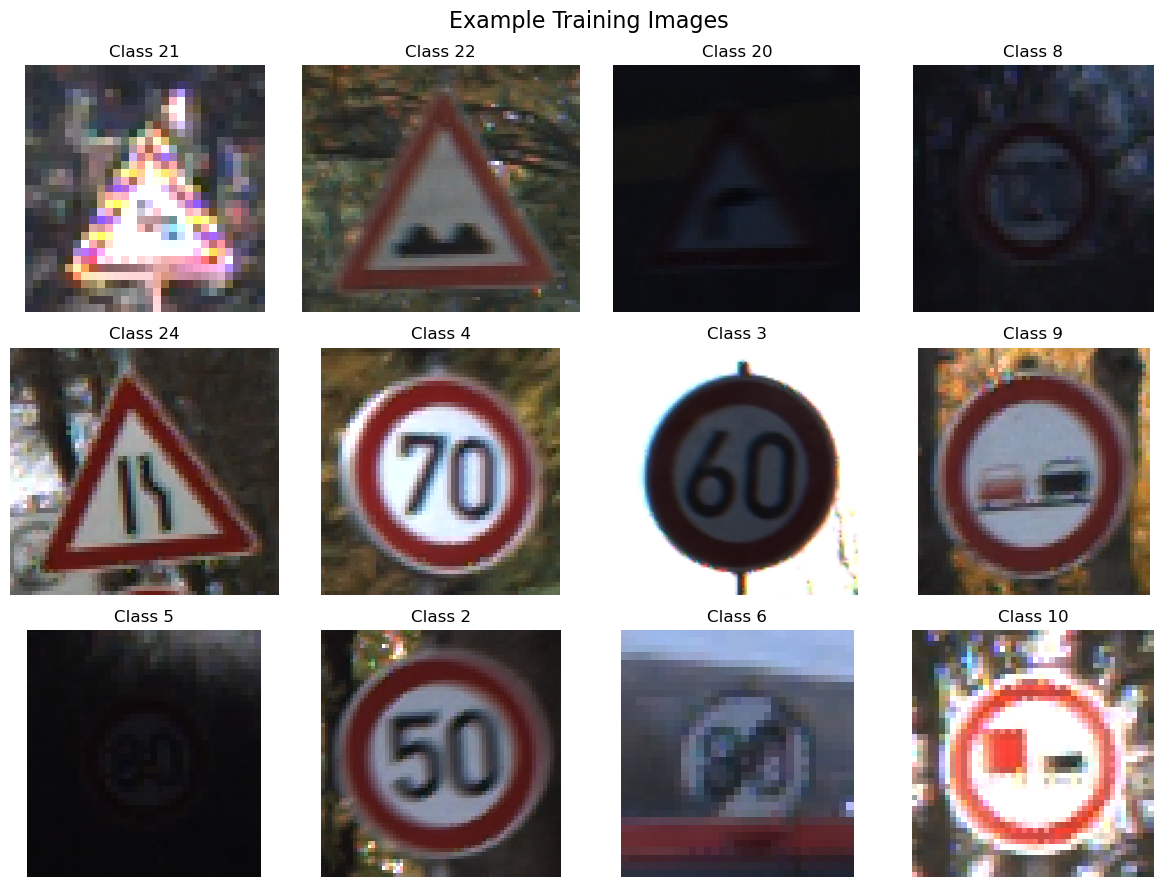

Sample figure saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/cnn_training_samples.png


In [13]:
# Display a random sample of training images
sample_size = 12
sample_df = train_df.sample(
    n=min(sample_size, len(train_df)),
    random_state=SEED
)

plt.figure(figsize=(12, 9))

for plot_index, (_, row) in enumerate(sample_df.iterrows(), start=1):
    image = Image.open(row["absolute_path"]).convert("RGB")

    plt.subplot(3, 4, plot_index)
    plt.imshow(image)
    plt.title(f"Class {row[LABEL_COLUMN]}")
    plt.axis("off")

plt.suptitle("Example Training Images", fontsize=16)
plt.tight_layout()

sample_figure_path = FIGURES_DIR / "cnn_training_samples.png"
plt.savefig(sample_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Sample figure saved to:", sample_figure_path)

##### 5. CNN Configuration

Image and training configuration. 

Load an image, convert it to RGB, resize it, and scale its pixel values to the range `[0, 1]`. 

`decode_image` does not automatically produce a fixed tensor shape.

In [14]:
IMAGE_HEIGHT = 32
IMAGE_WIDTH = 32
IMAGE_CHANNELS = 3

BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 0.001

AUTOTUNE = tf.data.AUTOTUNE

print("Image size:", (IMAGE_HEIGHT, IMAGE_WIDTH))
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

Image size: (32, 32)
Batch size: 64
Maximum epochs: 20
Learning rate: 0.001


In [15]:
def load_and_preprocess_image(image_path, label):
    image_bytes = tf.io.read_file(image_path)
    image = tf.io.decode_image(
        image_bytes,
        channels=IMAGE_CHANNELS,
        expand_animations=False
    )

    image.set_shape([None, None, IMAGE_CHANNELS])

    image = tf.image.resize(
        image,
        [IMAGE_HEIGHT, IMAGE_WIDTH]
    )

    image = tf.cast(image, tf.float32) / 255.0
    label = tf.cast(label, tf.int32)

    return image, label

##### 6. Build TensorFlow Datasets

Create a TensorFlow dataset from image paths and labels. 

In [16]:
def create_tf_dataset(dataframe, training=False):
    image_paths = dataframe["absolute_path"].astype(str).values
    labels = dataframe[LABEL_COLUMN].astype(np.int32).values

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_dataset = create_tf_dataset(train_df, training=True)
validation_dataset = create_tf_dataset(validation_df, training=False)
test_dataset = create_tf_dataset(test_df, training=False)

print("TensorFlow datasets created successfully.")

TensorFlow datasets created successfully.


In [17]:
# Inspect one batch to verify the tensor shapes
for image_batch, label_batch in train_dataset.take(1):
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("Image pixel range:",
          float(tf.reduce_min(image_batch)),
          "to",
          float(tf.reduce_max(image_batch)))
    print("Example labels:", label_batch[:10].numpy())

Image batch shape: (64, 32, 32, 3)
Label batch shape: (64,)
Image pixel range: 0.008903952315449715 to 1.0
Example labels: [12 25 15 38 16  1 30  9  3 35]


2026-06-20 18:55:22.827811: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


##### 7. Data Augmentation

Light data augmentation is used to improve generalisation. 

Horizontal flipping is deliberately not used because flipping a traffic sign can change its meaning or produce an unrealistic sign.

In [18]:
data_augmentation = keras.Sequential(
    [
        layers.RandomRotation(
            factor=0.08,
            fill_mode="nearest"
        ),
        layers.RandomTranslation(
            height_factor=0.08,
            width_factor=0.08,
            fill_mode="nearest"
        ),
        layers.RandomZoom(
            height_factor=(-0.10, 0.10),
            width_factor=(-0.10, 0.10),
            fill_mode="nearest"
        ),
        layers.RandomContrast(factor=0.10)
    ],
    name="data_augmentation"
)

##### 8. Build the CNN Baseline

Construct a simple CNN baseline model.

Architecture:
 - Data augmentation
 - Three convolutional blocks
 - Global average pooling
 - Dense classification layer

Compile the CNN using the Adam optimiser:

Sparse categorical cross-entropy is suitable because the target labels are stored as integer class IDs rather than one-hot encoded vectors.

In [19]:
def build_cnn_baseline(num_classes):
    model = keras.Sequential(
        [
            layers.Input(
                shape=(IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS)
            ),

            data_augmentation,

            # Convolutional block 1
            layers.Conv2D(
                32,
                kernel_size=(3, 3),
                padding="same",
                activation="relu"
            ),
            layers.BatchNormalization(),
            layers.Conv2D(
                32,
                kernel_size=(3, 3),
                padding="same",
                activation="relu"
            ),
            layers.MaxPooling2D(pool_size=(2, 2)),
            layers.Dropout(0.20),

            # Convolutional block 2
            layers.Conv2D(
                64,
                kernel_size=(3, 3),
                padding="same",
                activation="relu"
            ),
            layers.BatchNormalization(),
            layers.Conv2D(
                64,
                kernel_size=(3, 3),
                padding="same",
                activation="relu"
            ),
            layers.MaxPooling2D(pool_size=(2, 2)),
            layers.Dropout(0.25),

            # Convolutional block 3
            layers.Conv2D(
                128,
                kernel_size=(3, 3),
                padding="same",
                activation="relu"
            ),
            layers.BatchNormalization(),
            layers.MaxPooling2D(pool_size=(2, 2)),
            layers.Dropout(0.30),

            # Classification layers
            layers.GlobalAveragePooling2D(),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.40),
            layers.Dense(num_classes, activation="softmax")
        ],
        name="cnn_baseline"
    )

    return model


cnn_model = build_cnn_baseline(NUM_CLASSES)

cnn_model.summary()

Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,379 (634.29 KB)

 Trainable params: 161,931 (632.54 KB)

 Non-trainable params: 448 (1.75 KB)

In [20]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("CNN model compiled successfully.")

CNN model compiled successfully.


In [21]:
BEST_MODEL_PATH = MODEL_DIR / "cnn_baseline_best.keras"
FINAL_MODEL_PATH = MODEL_DIR / "cnn_baseline_final.keras"

callbacks = [
    # Stop training when validation loss no longer improves
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # Save the model with the lowest validation loss
    keras.callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    # Reduce the learning rate if validation performance stops improving
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Callbacks configured.")
print("Best model will be saved to:", BEST_MODEL_PATH)

Callbacks configured.
Best model will be saved to: /Users/liuyuhan/Desktop/traffic_recognition/models/cnn_baseline_best.keras


##### 9. Train Model

Train the CNN baseline model and save training history by converting the Keras history object into a DataFrame.

In [22]:
training_start_time = time.time()

history = cnn_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

training_end_time = time.time()
training_duration_seconds = training_end_time - training_start_time

print(
    f"\nTraining completed in "
    f"{training_duration_seconds / 60:.2f} minutes."
)

Epoch 1/20
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.1615 - loss: 3.0992
Epoch 1: val_loss improved from inf to 4.76603, saving model to /Users/liuyuhan/Desktop/traffic_recognition/models/cnn_baseline_best.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 108s 210ms/step - accuracy: 0.1618 - loss: 3.0976 - val_accuracy: 0.0362 - val_loss: 4.7660 - learning_rate: 0.0010
Epoch 2/20
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.4535 - loss: 1.7324
Epoch 2: val_loss improved from 4.76603 to 1.37117, saving model to /Users/liuyuhan/Desktop/traffic_recognition/models/cnn_baseline_best.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 101s 206ms/step - accuracy: 0.4538 - loss: 1.7315 - val_accuracy: 0.5773 - val_loss: 1.3712 - learning_rate: 0.0010
Epoch 3/20
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.6894 - loss: 0.9424
Epoch 3: val_loss improved from 1.37117 to 0.56780, saving model to /Users/liuyuhan/Desktop/traffic_recognition/models/cnn_baseline_best.keras
491/491 ━━━━━━━━━━━━━

In [23]:
history_df = pd.DataFrame(history.history)
history_df.index = np.arange(1, len(history_df) + 1)
history_df.index.name = "epoch"

history_output_path = RESULTS_DIR / "cnn_baseline_history.csv"
history_df.to_csv(history_output_path)

display(history_df)

print("Training history saved to:", history_output_path)

,accuracy,loss,val_accuracy,val_loss,learning_rate
epoch,,,,,
1,0.233972,2.702754,0.036215,4.766032,0.0010
2,0.515223,1.504006,0.577276,1.371173,0.0010
3,0.741926,0.783467,0.818286,0.567796,0.0010
4,0.855389,0.447886,0.955496,0.157877,0.0010
5,0.908917,0.295509,0.934200,0.222281,0.0010
6,0.929990,0.228035,0.987758,0.049632,0.0010
7,0.938566,0.195278,0.988906,0.045647,0.0010
8,0.954538,0.147399,0.982275,0.058947,0.0010
9,0.957280,0.137168,0.992221,0.028590,0.0010


Training history saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/cnn_baseline_history.csv


##### 10. Validation and Test Evaluation

The models are evaluated by following steps:

- Plot and compare training validation and test accuracy and loss;
- Load the checkpoint with the lowest validation loss;
- Evaluate the best model on the validation and test datasets;
- Generate class probability predictions for the test set;
- Independently calculate accuracy using scikit-learn.




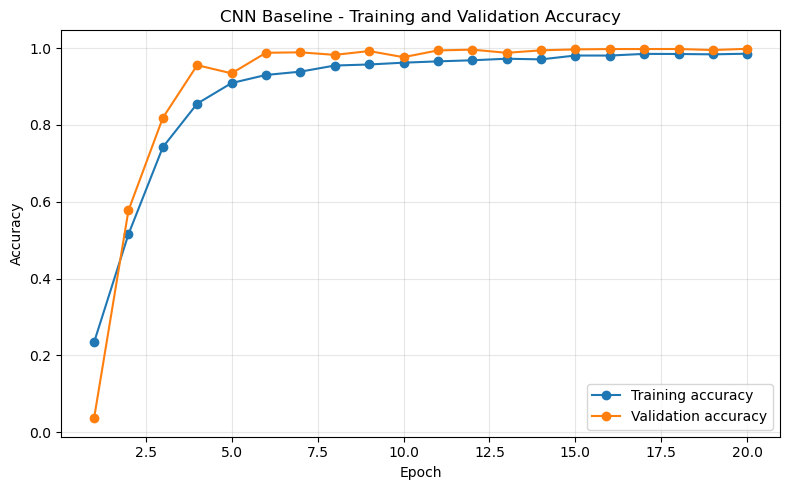

Accuracy plot saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/cnn_baseline_accuracy.png


In [25]:
# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history_df.index,
    history_df["accuracy"],
    marker="o",
    label="Training accuracy"
)

plt.plot(
    history_df.index,
    history_df["val_accuracy"],
    marker="o",
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Baseline - Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

accuracy_plot_path = FIGURES_DIR / "cnn_baseline_accuracy.png"
plt.savefig(accuracy_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Accuracy plot saved to:", accuracy_plot_path)

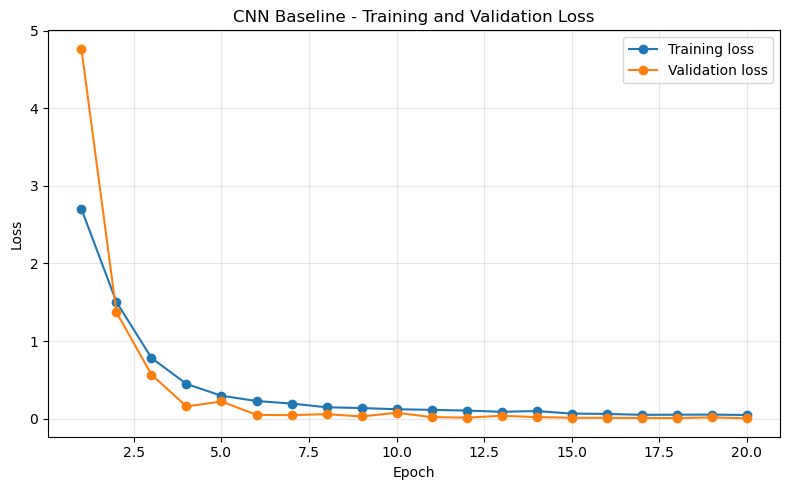

Loss plot saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/cnn_baseline_loss.png


In [26]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(
    history_df.index,
    history_df["loss"],
    marker="o",
    label="Training loss"
)

plt.plot(
    history_df.index,
    history_df["val_loss"],
    marker="o",
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Baseline - Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

loss_plot_path = FIGURES_DIR / "cnn_baseline_loss.png"
plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Loss plot saved to:", loss_plot_path)

In [27]:
# Load the best model
if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"The best model checkpoint was not found at {BEST_MODEL_PATH}"
    )

best_cnn_model = keras.models.load_model(BEST_MODEL_PATH)

print("Best CNN model loaded from:", BEST_MODEL_PATH)

Best CNN model loaded from: /Users/liuyuhan/Desktop/traffic_recognition/models/cnn_baseline_best.keras


In [28]:
validation_loss, validation_accuracy = best_cnn_model.evaluate(
    validation_dataset,
    verbose=1
)

test_loss, test_accuracy = best_cnn_model.evaluate(
    test_dataset,
    verbose=1
)

print("\nValidation results")
print("------------------")
print(f"Validation loss: {validation_loss:.4f}")
print(f"Validation accuracy: {validation_accuracy:.4f}")
print(f"Validation accuracy: {validation_accuracy * 100:.2f}%")

print("\nTest results")
print("------------")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9982 - loss: 0.0038
198/198 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9711 - loss: 0.1397

Validation results
------------------
Validation loss: 0.0058
Validation accuracy: 0.9981
Validation accuracy: 99.81%

Test results
------------
Test loss: 0.1501
Test accuracy: 0.9697
Test accuracy: 96.97%


In [29]:
# Generate predictions
prediction_start_time = time.time()

test_probabilities = best_cnn_model.predict(
    test_dataset,
    verbose=1
)

prediction_end_time = time.time()

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)

test_true_labels = test_df[LABEL_COLUMN].to_numpy()

prediction_duration_seconds = (
    prediction_end_time - prediction_start_time
)

print("Prediction array shape:", test_probabilities.shape)
print("Number of predicted labels:", len(test_predictions))
print(
    f"Prediction time: {prediction_duration_seconds:.2f} seconds"
)

198/198 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step
Prediction array shape: (12630, 43)
Number of predicted labels: 12630
Prediction time: 7.79 seconds


In [30]:
# Confirm test accuracy
sklearn_test_accuracy = accuracy_score(
    test_true_labels,
    test_predictions
)

print(
    f"Scikit-learn test accuracy: "
    f"{sklearn_test_accuracy:.4f}"
)

print(
    f"Scikit-learn test accuracy: "
    f"{sklearn_test_accuracy * 100:.2f}%"
)

Scikit-learn test accuracy: 0.9697
Scikit-learn test accuracy: 96.97%


##### 11. Classification Report

The classification report contains class-level:

- **precision**.
- **recall**.
- **F1-score**.

Extract the overall and averaged performance metrics:

- **Macro precision**: precision calculated separately for every class and then averaged.
- **Macro recall**: recall calculated separately for every class and then averaged.
- **Macro F1-score**: F1-score calculated separately for every class and then averaged.
- **Weighted precision**: class precision weighted according to class size.
- **Weighted recall**: class recall weighted according to class size.
- **Weighted F1-score**: class F1-scores weighted according to class size.



In [31]:
classification_report_dict = classification_report(
    test_true_labels,
    test_predictions,
    labels=CLASS_IDS,
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(
    classification_report_dict
).transpose()

classification_report_path = (
    RESULTS_DIR / "cnn_baseline_classification_report.csv"
)

classification_report_df.to_csv(
    classification_report_path,
    index=True
)

display(classification_report_df.tail())

print(
    "Classification report saved to:",
    classification_report_path
)

,precision,recall,f1-score,support
41,0.983607,1.000000,0.991736,60.000000
42,1.000000,0.766667,0.867925,90.000000
accuracy,0.969675,0.969675,0.969675,0.969675
macro avg,0.950243,0.950050,0.947397,12630.000000
weighted avg,0.972299,0.969675,0.969764,12630.000000


Classification report saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/cnn_baseline_classification_report.csv


In [32]:
macro_precision = classification_report_dict[
    "macro avg"
]["precision"]

macro_recall = classification_report_dict[
    "macro avg"
]["recall"]

macro_f1 = classification_report_dict[
    "macro avg"
]["f1-score"]

weighted_precision = classification_report_dict[
    "weighted avg"
]["precision"]

weighted_recall = classification_report_dict[
    "weighted avg"
]["recall"]

weighted_f1 = classification_report_dict[
    "weighted avg"
]["f1-score"]

print(f"Test accuracy: {sklearn_test_accuracy:.4f}")
print(f"Macro precision: {macro_precision:.4f}")
print(f"Macro recall: {macro_recall:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")
print(f"Weighted precision: {weighted_precision:.4f}")
print(f"Weighted recall: {weighted_recall:.4f}")
print(f"Weighted F1-score: {weighted_f1:.4f}")

Test accuracy: 0.9697
Macro precision: 0.9502
Macro recall: 0.9500
Macro F1-score: 0.9474
Weighted precision: 0.9723
Weighted recall: 0.9697
Weighted F1-score: 0.9698


##### 12. Confusion Matrices

In a confusion matrix:

- rows represent the true classes;
- columns represent the predicted classes;
- diagonal values represent correct classifications;
- off-diagonal values represent classification errors.

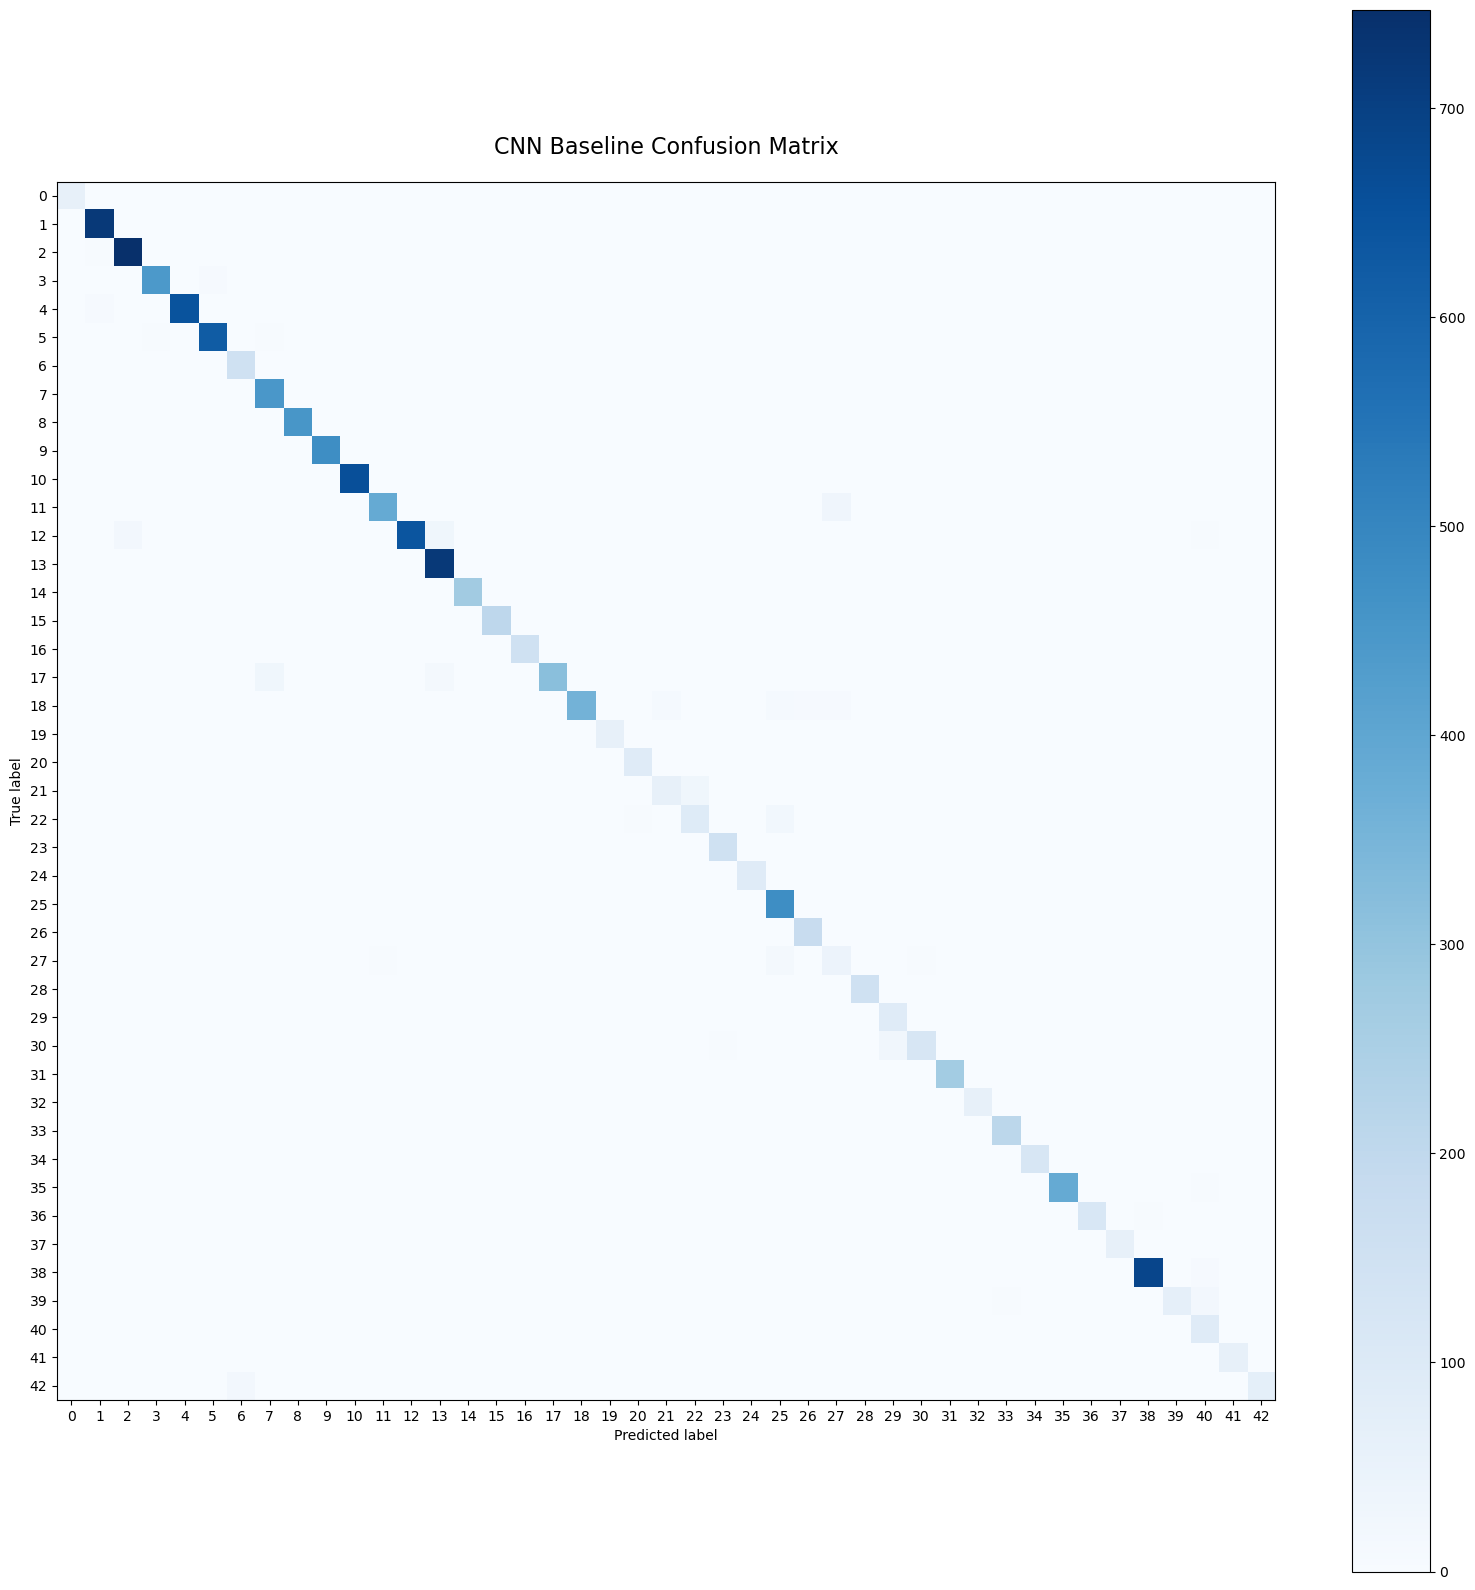

Confusion matrix saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/cnn_baseline_confusion_matrix.png


In [33]:
cnn_confusion_matrix = confusion_matrix(
    test_true_labels,
    test_predictions,
    labels=CLASS_IDS
)

fig, ax = plt.subplots(figsize=(16, 16))

display_object = ConfusionMatrixDisplay(
    confusion_matrix=cnn_confusion_matrix,
    display_labels=CLASS_IDS
)

display_object.plot(
    ax=ax,
    cmap="Blues",
    colorbar=True,
    include_values=False
)

ax.set_title(
    "CNN Baseline Confusion Matrix",
    fontsize=16,
    pad=20
)

plt.tight_layout()

confusion_matrix_path = (
    FIGURES_DIR / "cnn_baseline_confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Confusion matrix saved to:",
    confusion_matrix_path
)

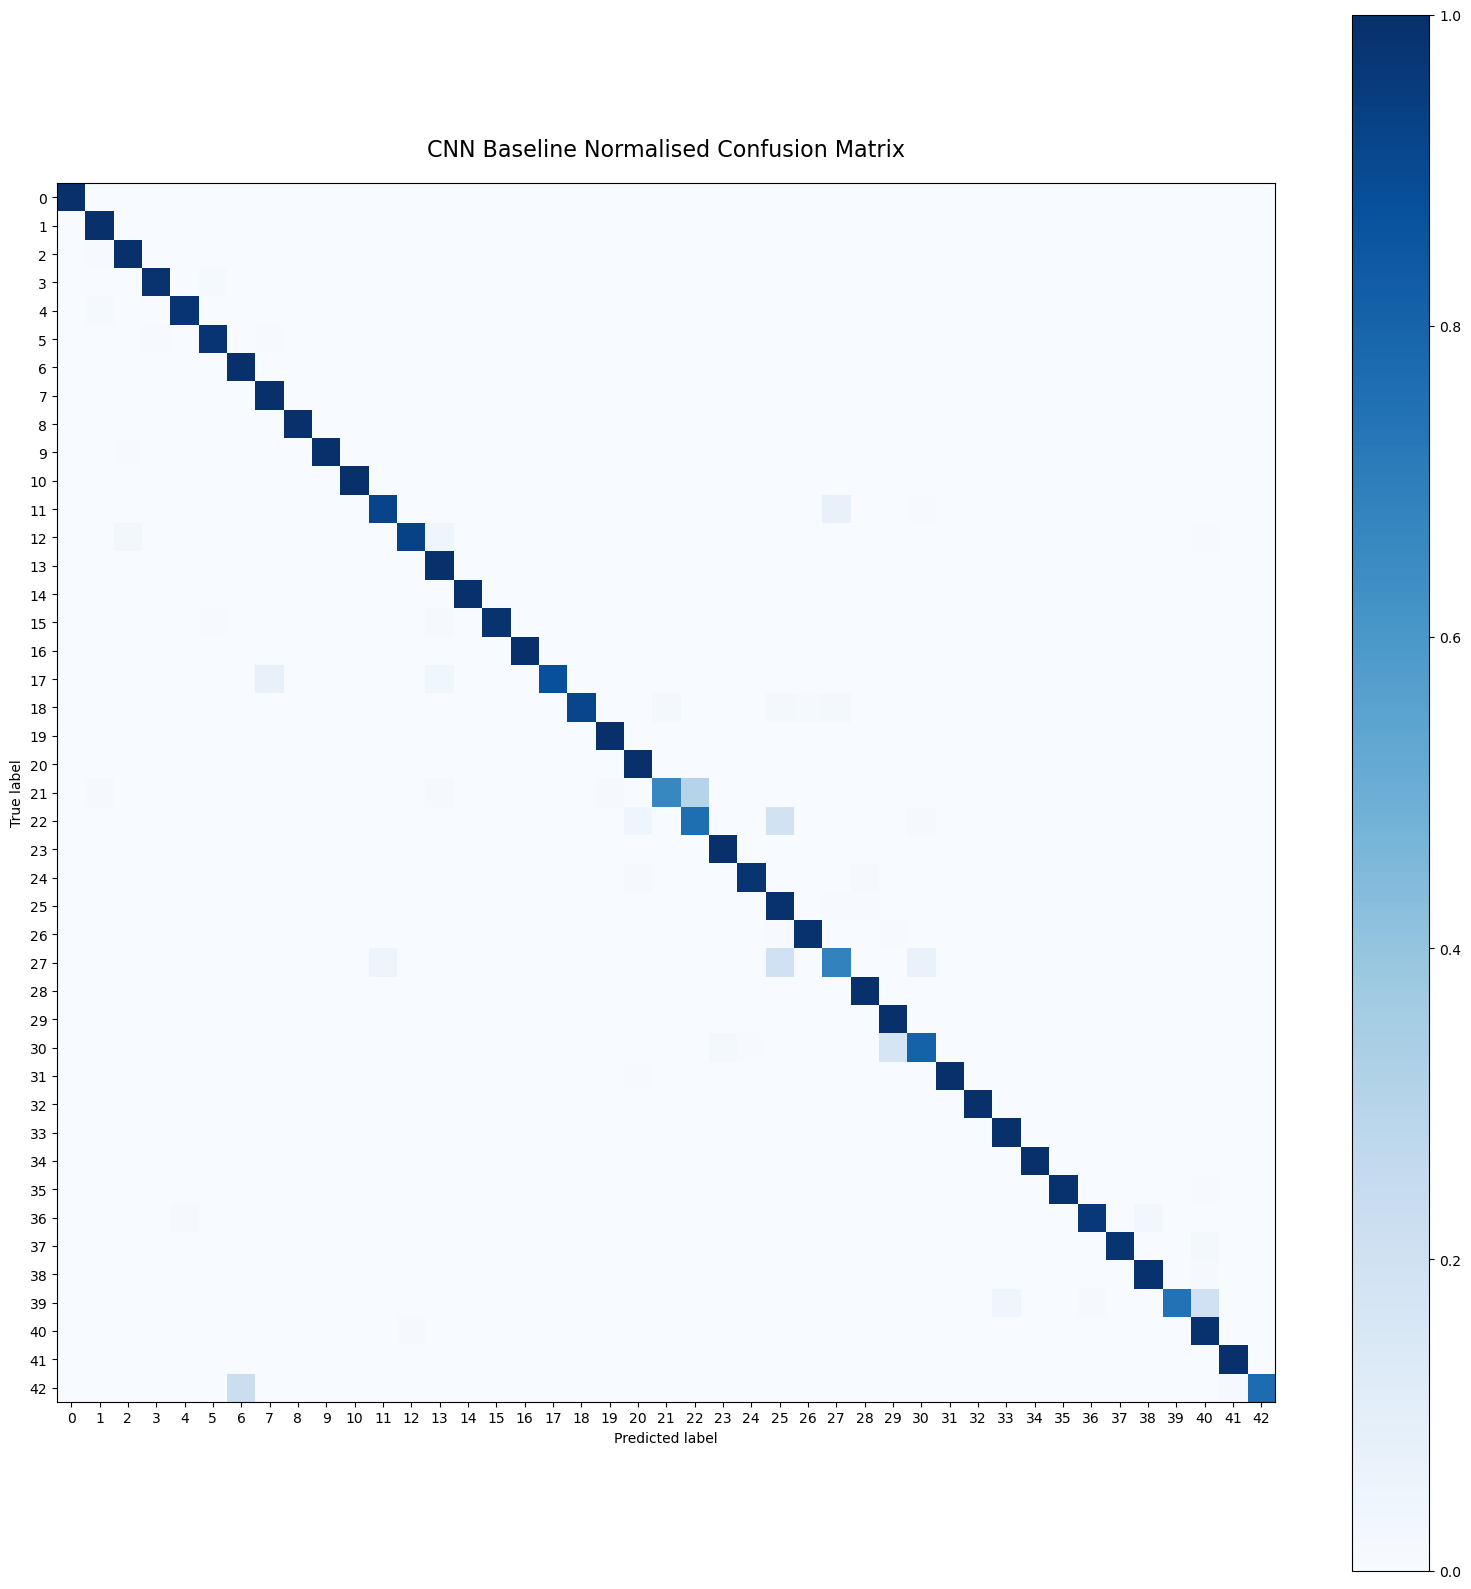

Normalised confusion matrix saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/cnn_baseline_normalised_confusion_matrix.png


In [38]:
cnn_normalised_confusion_matrix = confusion_matrix(
    test_true_labels,
    test_predictions,
    labels=CLASS_IDS,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(16, 16))

display_object = ConfusionMatrixDisplay(
    confusion_matrix=cnn_normalised_confusion_matrix,
    display_labels=CLASS_IDS
)

display_object.plot(
    ax=ax,
    cmap="Blues",
    colorbar=True,
    include_values=False
)

ax.set_title(
    "CNN Baseline Normalised Confusion Matrix",
    fontsize=16,
    pad=20
)

plt.tight_layout()

normalised_cm_path = (
    FIGURES_DIR / "cnn_baseline_normalised_confusion_matrix.png"
)

plt.savefig(
    normalised_cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Normalised confusion matrix saved to:", normalised_cm_path)

##### 13. Per-class Performance

Calculate accuracy separately for each traffic-sign class.

The diagonal of the row-normalised confusion matrix represents recall for each class.

A high value means that most images belonging to that class were identified correctly.

In [34]:
class_totals = cnn_confusion_matrix.sum(axis=1)
class_correct = np.diag(cnn_confusion_matrix)

class_accuracy = np.divide(
    class_correct,
    class_totals,
    out=np.zeros_like(class_correct, dtype=float),
    where=class_totals != 0
)

per_class_accuracy_df = pd.DataFrame(
    {
        "class_id": CLASS_IDS,
        "correct_predictions": class_correct,
        "total_samples": class_totals,
        "class_accuracy": class_accuracy
    }
)

per_class_accuracy_df = per_class_accuracy_df.sort_values(
    by="class_accuracy",
    ascending=False
).reset_index(drop=True)

per_class_accuracy_path = (
    RESULTS_DIR / "cnn_baseline_per_class_accuracy.csv"
)

per_class_accuracy_df.to_csv(
    per_class_accuracy_path,
    index=False
)

display(per_class_accuracy_df.head(10))

print(
    "Per-class accuracy saved to:",
    per_class_accuracy_path
)

,class_id,correct_predictions,total_samples,class_accuracy
0,0,60,60,1.0
1,8,450,450,1.0
2,6,150,150,1.0
3,28,150,150,1.0
4,29,90,90,1.0
5,33,210,210,1.0
6,23,150,150,1.0
7,19,60,60,1.0
8,20,90,90,1.0
9,16,150,150,1.0


Per-class accuracy saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/cnn_baseline_per_class_accuracy.csv


In [35]:
# Best and worst performing classes
print("Five best-performing classes:")
display(
    per_class_accuracy_df.head(5)
)

print("\nFive worst-performing classes:")
display(
    per_class_accuracy_df.tail(5).sort_values(
        by="class_accuracy"
    )
)

Five best-performing classes:


,class_id,correct_predictions,total_samples,class_accuracy
0,0,60,60,1.0
1,8,450,450,1.0
2,6,150,150,1.0
3,28,150,150,1.0
4,29,90,90,1.0



Five worst-performing classes:


,class_id,correct_predictions,total_samples,class_accuracy
42,21,60,90,0.666667
41,27,41,60,0.683333
40,39,67,90,0.744444
39,22,91,120,0.758333
38,42,69,90,0.766667


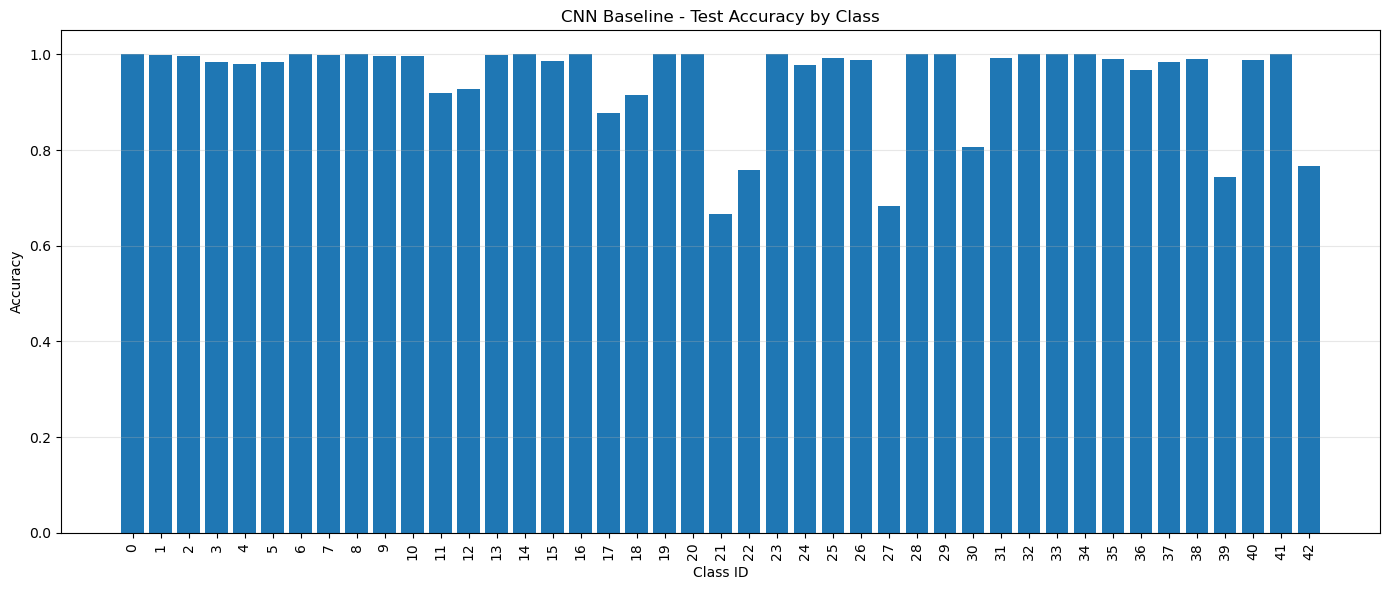

Per-class accuracy plot saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/cnn_baseline_per_class_accuracy.png


In [36]:
# Plot per-class accuracy, sort classes by class ID
plot_class_accuracy_df = per_class_accuracy_df.sort_values(
    by="class_id"
)

plt.figure(figsize=(14, 6))

plt.bar(
    plot_class_accuracy_df["class_id"].astype(str),
    plot_class_accuracy_df["class_accuracy"]
)

plt.xlabel("Class ID")
plt.ylabel("Accuracy")
plt.title("CNN Baseline - Test Accuracy by Class")
plt.ylim(0, 1.05)
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

class_accuracy_plot_path = (
    FIGURES_DIR / "cnn_baseline_per_class_accuracy.png"
)

plt.savefig(
    class_accuracy_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Per-class accuracy plot saved to:",
    class_accuracy_plot_path
)

Number of incorrect predictions: 383


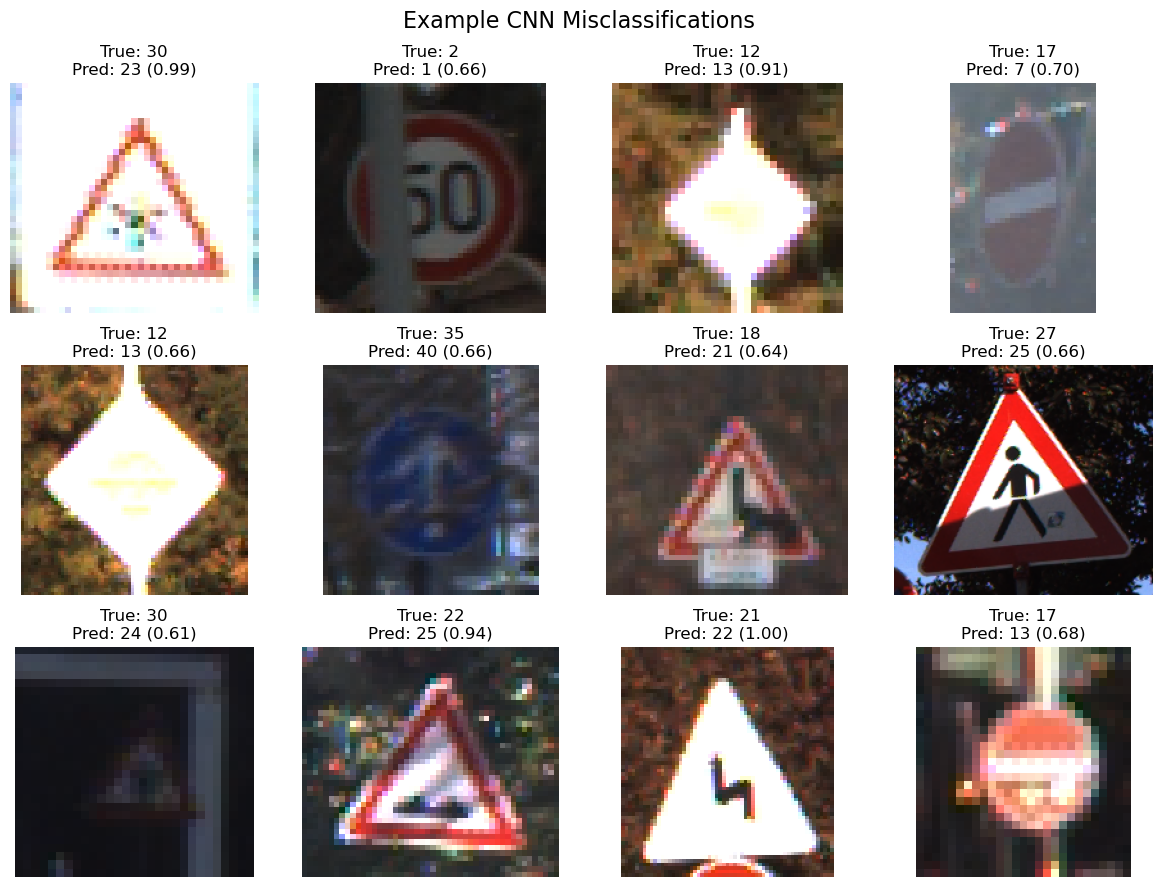

Misclassification examples saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/cnn_baseline_misclassifications.png


In [37]:
# Display misclassified examples, identify incorrectly classified test images
incorrect_indices = np.where(
    test_true_labels != test_predictions
)[0]

print("Number of incorrect predictions:", len(incorrect_indices))

if len(incorrect_indices) > 0:
    rng = np.random.default_rng(SEED)

    selected_indices = rng.choice(
        incorrect_indices,
        size=min(12, len(incorrect_indices)),
        replace=False
    )

    plt.figure(figsize=(12, 9))

    for plot_index, test_index in enumerate(
        selected_indices,
        start=1
    ):
        image_path = test_df.iloc[test_index]["absolute_path"]
        image = Image.open(image_path).convert("RGB")

        true_label = test_true_labels[test_index]
        predicted_label = test_predictions[test_index]
        confidence = test_probabilities[
            test_index,
            predicted_label
        ]

        plt.subplot(3, 4, plot_index)
        plt.imshow(image)
        plt.title(
            f"True: {true_label}\n"
            f"Pred: {predicted_label} "
            f"({confidence:.2f})"
        )
        plt.axis("off")

    plt.suptitle(
        "Example CNN Misclassifications",
        fontsize=16
    )
    plt.tight_layout()

    misclassification_path = (
        FIGURES_DIR / "cnn_baseline_misclassifications.png"
    )

    plt.savefig(
        misclassification_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Misclassification examples saved to:",
        misclassification_path
    )
else:
    print("No misclassified examples were found.")

##### 14. Save Individual Test Predictions

Saving each prediction allows later inspection of:

- correctly classified images;
- incorrectly classified images;
- common confusion pairs;
- difficult classes.

In [39]:
prediction_results_df = test_df[
    [PATH_COLUMN, LABEL_COLUMN]
].copy()

prediction_results_df = prediction_results_df.rename(
    columns={
        LABEL_COLUMN: "true_class"
    }
)

prediction_results_df["predicted_class"] = test_predictions
prediction_results_df["correct"] = (
    prediction_results_df["true_class"]
    == prediction_results_df["predicted_class"]
)

prediction_results_df["prediction_confidence"] = (
    np.max(test_probabilities, axis=1)
)

predictions_path = (
    RESULTS_DIR / "cnn_baseline_test_predictions.csv"
)

prediction_results_df.to_csv(
    predictions_path,
    index=False
)

display(prediction_results_df.head())

print("Test predictions saved to:", predictions_path)

,Path,true_class,predicted_class,correct,prediction_confidence
0,Test/00000.png,16,16,True,1.000000
1,Test/00001.png,1,1,True,1.000000
2,Test/00002.png,38,38,True,1.000000
3,Test/00003.png,33,33,True,1.000000
4,Test/00004.png,11,11,True,0.999855


Test predictions saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/cnn_baseline_test_predictions.csv


##### 15. Save Experiment Summary

Create a single-row summary of the CNN experiment

In [40]:
best_epoch = int(
    history_df["val_loss"].idxmin()
)

best_validation_loss = float(
    history_df.loc[best_epoch, "val_loss"]
)

best_validation_accuracy = float(
    history_df.loc[best_epoch, "val_accuracy"]
)

experiment_summary = pd.DataFrame(
    [
        {
            "model": "CNN baseline",
            "image_height": IMAGE_HEIGHT,
            "image_width": IMAGE_WIDTH,
            "batch_size": BATCH_SIZE,
            "maximum_epochs": EPOCHS,
            "epochs_completed": len(history_df),
            "best_epoch": best_epoch,
            "learning_rate": LEARNING_RATE,
            "number_of_classes": NUM_CLASSES,
            "training_samples": len(train_df),
            "validation_samples": len(validation_df),
            "test_samples": len(test_df),
            "best_validation_loss": best_validation_loss,
            "best_validation_accuracy": best_validation_accuracy,
            "final_validation_loss": validation_loss,
            "final_validation_accuracy": validation_accuracy,
            "test_loss": test_loss,
            "test_accuracy": sklearn_test_accuracy,
            "macro_precision": macro_precision,
            "macro_recall": macro_recall,
            "macro_f1": macro_f1,
            "weighted_precision": weighted_precision,
            "weighted_recall": weighted_recall,
            "weighted_f1": weighted_f1,
            "training_time_seconds": training_duration_seconds,
            "prediction_time_seconds": prediction_duration_seconds,
            "random_seed": SEED
        }
    ]
)

experiment_summary_path = (
    RESULTS_DIR / "cnn_baseline_summary.csv"
)

experiment_summary.to_csv(
    experiment_summary_path,
    index=False
)

display(experiment_summary.T)

print(
    "Experiment summary saved to:",
    experiment_summary_path
)

,0
model,CNN baseline
image_height,32
image_width,32
batch_size,64
maximum_epochs,20
epochs_completed,20
best_epoch,20
learning_rate,0.001
number_of_classes,43
training_samples,31367


Experiment summary saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/cnn_baseline_summary.csv


##### 16. Save Final Model

Save the final restored best model under a clear final filename.


In [41]:
best_cnn_model.save(FINAL_MODEL_PATH)

print("Final CNN model saved to:", FINAL_MODEL_PATH)

Final CNN model saved to: /Users/liuyuhan/Desktop/traffic_recognition/models/cnn_baseline_final.keras


In [43]:
# List the key files generated by this notebook

generated_files = [
    BEST_MODEL_PATH,
    FINAL_MODEL_PATH,
    history_output_path,
    classification_report_path,
    per_class_accuracy_path,
    predictions_path,
    experiment_summary_path,
    accuracy_plot_path,
    loss_plot_path,
    confusion_matrix_path,
    normalised_cm_path,
    class_accuracy_plot_path
]

print("Generated output files")
print("----------------------")

for output_file in generated_files:
    status = "FOUND" if output_file.exists() else "MISSING"
    print(f"{status:8} | {output_file}")

Generated output files
----------------------
FOUND    | /Users/liuyuhan/Desktop/traffic_recognition/models/cnn_baseline_best.keras
FOUND    | /Users/liuyuhan/Desktop/traffic_recognition/models/cnn_baseline_final.keras
FOUND    | /Users/liuyuhan/Desktop/traffic_recognition/results/cnn_baseline_history.csv
FOUND    | /Users/liuyuhan/Desktop/traffic_recognition/results/cnn_baseline_classification_report.csv
FOUND    | /Users/liuyuhan/Desktop/traffic_recognition/results/cnn_baseline_per_class_accuracy.csv
FOUND    | /Users/liuyuhan/Desktop/traffic_recognition/results/cnn_baseline_test_predictions.csv
FOUND    | /Users/liuyuhan/Desktop/traffic_recognition/results/cnn_baseline_summary.csv
FOUND    | /Users/liuyuhan/Desktop/traffic_recognition/results/figures/cnn_baseline_accuracy.png
FOUND    | /Users/liuyuhan/Desktop/traffic_recognition/results/figures/cnn_baseline_loss.png
FOUND    | /Users/liuyuhan/Desktop/traffic_recognition/results/figures/cnn_baseline_confusion_matrix.png
FOUND    | /

##### 17. Compare CNN with HOG-SVM

Attempt to locate the HOG-SVM baseline results. This comparison is optional and will not stop the notebook if the HOG-SVM summary file is not available.

In [ ]:
possible_hog_summary_files = [
    RESULTS_DIR / "hog_svm_summary.csv",
    RESULTS_DIR / "hog_svm_baseline_summary.csv",
    RESULTS_DIR / "hog_svm_metrics.csv"
]

hog_summary_path = next(
    (
        path for path in possible_hog_summary_files
        if path.exists()
    ),
    None
)

if hog_summary_path is None:
    print(
        "No HOG-SVM summary CSV was found. "
        "The CNN results have still been saved successfully."
    )
else:
    hog_summary_df = pd.read_csv(hog_summary_path)

    print("HOG-SVM summary loaded from:", hog_summary_path)
    display(hog_summary_df)